##### Import statements:

In [143]:
import os
import pathlib
import sys
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from analysis_metadata.analysis_metadata import Metadata, increment_dir_name, write_metadata

##### Define inputs, parameters:

In [161]:
# Input file:
input_path = os.path.join('/', 'mnt', 'smb', 'locker', 'issa-locker', 'users', 'Dan', 'code', 'ws', 'results', 'run816', 'iterate_entangler.pickle')
input_dir = os.path.split(input_path)[0]

# Output parameters:
save_output = True
base_dir_name = 'pr_v_beta_pr'

##### Load previously-saved results:

In [162]:
iterate_mdl_results = pickle.load(open(input_path, 'rb'))

##### Find aymptotic participation ratio for all models:

In [163]:
loss_df = iterate_mdl_results['ae_df']
loss_df_ae = loss_df[loss_df.mdl_type=='autoencoder']
max_epoch_df = loss_df_ae[['mdl_id', 'epoch']].groupby('mdl_id').apply(lambda x : np.max(x.epoch)).reset_index(name='epoch')
loss_pr_df = pd.merge(loss_df_ae, max_epoch_df, on=['mdl_id', 'epoch'])

##### Average across repeats:

In [164]:
Mu = loss_pr_df[['beta_pr', 'loss_pr']].groupby('beta_pr').mean().reset_index()
Sig = loss_pr_df[['beta_pr', 'loss_pr']].groupby('beta_pr').std().reset_index()

##### Plot asymptotic participation ratio vs. $\beta_{\text{PR}}$:

(68.0, 80.0)

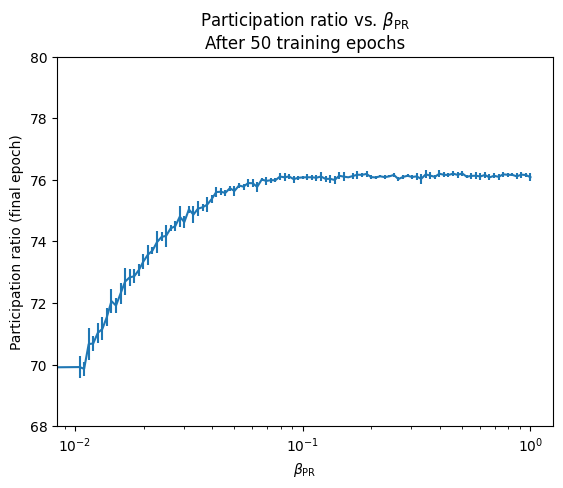

In [167]:
f = plt.figure()
plt.errorbar(Mu.beta_pr, Mu.loss_pr, yerr=Sig.loss_pr)
plt.xscale('log')
plt.ylabel('Participation ratio (final epoch)')
plt.xlabel(r'$\beta_{\text{PR}}$')

# Title
title_base = 'Participation ratio vs. ' + r'$\beta_{\text{PR}}$'
if len(np.unique(max_epoch_df.epoch)) == 1:
    max_epoch = max_epoch_df.iloc[0].epoch
    max_epoch_str = 'After {} training epochs'.format(int(max_epoch+1))
else:
    max_epoch_str = []

title_lines = []
title_lines.append(title_base)
title_lines.append(max_epoch_str)
title = '\n'.join(title_lines)
plt.title(title)
plt.ylim([68,80])

##### Save output:

In [168]:
if save_output:

    # Create output directory:
    curr_output_directory = increment_dir_name(input_dir, base_dir_name)
    if not os.path.exists(curr_output_directory):
        pathlib.Path(curr_output_directory).mkdir(parents=True,exist_ok=True)

    # Save figures:
    plt.figure(f)
    file_basename = 'pr_v_beta_pr'
    png_path = os.path.join(curr_output_directory, file_basename+'.png')
    plt.savefig(png_path)
    svg_path =  os.path.join(curr_output_directory, file_basename+'.svg')
    plt.savefig(svg_path)

    # Define metadata:
    M = Metadata()
    M.add_input(input_path)
    M.add_output(png_path)
    M.add_output(svg_path)
    metadata_path = os.path.join(curr_output_directory, 'pr_v_beta_pr_metadata.json')
    write_metadata(M, metadata_path)

Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run816/iterate_entangler.pickle...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run816/pr_v_beta_pr001/pr_v_beta_pr.png...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run816/pr_v_beta_pr001/pr_v_beta_pr.svg...
